# EDA: Node Attribute Selection for `SEAL_directed`

This notebook documents the exploratory analysis used to decide which GATEWAy columns should be converted into node attributes for the directed SEAL/DGCNN pipeline.

The goal is not only to report missingness, but to justify a practical feature ranking based on:

- coverage in the raw dataset,
- ecological relevance for trophic link prediction,
- whether the feature is safe to use without leaking test edges,
- compatibility with the current SEAL/DGCNN implementation.

## Summary of the Decision

The current `SEAL_directed` node attribute matrix, stored as `group` in the attributed `.mat` files, uses:

1. `log10_mass_z`
2. `mass_missing`
3. `taxonomy_level` one-hot features
4. `metabolic_type` one-hot features
5. `movement_type` one-hot features
6. `lifestage_missing`
7. `lifestage` one-hot features

We intentionally do **not** include graph-derived features such as degree, trophic level, clustering, generality, or vulnerability in this first version, because they must be recomputed from the training graph only to avoid leakage.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)

In [ ]:
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data/raw/283_3_Dataset").exists() and (candidate / "src/python/seal_directed").exists():
            return candidate
    raise RuntimeError("Could not find project root from the current working directory.")


PROJECT_ROOT = find_project_root()
RAW_CSV = PROJECT_ROOT / "data/raw/283_3_Dataset/283_2_FoodWebDataBase_2018_12_10.csv"
ATTR_DIR = PROJECT_ROOT / "src/python/seal_directed/data/foodwebs_mat_seal_attrs"
FEATURE_NAMES_CSV = ATTR_DIR / "seal_node_attribute_feature_names.csv"
BUILD_SUMMARY_CSV = ATTR_DIR / "seal_node_attribute_build_summary.csv"
FIG_DIR = PROJECT_ROOT / "docs/plots/seal_directed_node_attribute_eda"
SAVE_FIGURES = False

if SAVE_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw CSV: {RAW_CSV}")
print(f"Attributed MAT folder: {ATTR_DIR}")

Project root: /Users/acw792/Developer/qmul-phd-framework
Raw CSV: /Users/acw792/Developer/qmul-phd-framework/data/raw/283_3_Dataset/283_2_FoodWebDataBase_2018_12_10.csv
Attributed MAT folder: /Users/acw792/Developer/qmul-phd-framework/src/python/seal_directed/data/foodwebs_mat_seal_attrs


In [3]:
raw = pd.read_csv(RAW_CSV, low_memory=False)
print(f"Rows: {raw.shape[0]:,}")
print(f"Columns: {raw.shape[1]:,}")
print(f"Food webs: {raw['foodweb.name'].nunique():,}")
raw.head()

Rows: 222,151
Columns: 46
Food webs: 290


,autoID,link.citation,link.methodology,interaction.type,interaction.dimensionality,interaction.classification,con.taxonomy,con.taxonomy.level,con.common,con.lifestage,con.metabolic.type,con.movement.type,con.size.citation,con.size.method,con.length.min.cm.,con.length.mean.cm.,con.length.max.cm.,con.mass.min.g.,con.mass.mean.g.,con.mass.max.g.,res.taxonomy,res.taxonomy.level,res.common,res.lifestage,res.metabolic.type,res.movement.type,res.size.citation,res.size.method,res.length.min.cm.,res.length.mean.cm.,res.length.max.cm.,res.mass.min.g.,res.mass.mean.g.,res.mass.max.g.,geographic.location,longitude,latitude,ecosystem.type,study.site,altitude,depth,sampling.time,sampling.start.year,sampling.end.year,notes,foodweb.name
0,1,Cattin Blandenier (2004),published account internet field natural history,predacious,NaN,ibi,Vulpes vulpes,NaN,NaN,NaN,endotherm vertebrate,walking,Cattin Blandenier (2004),measurement published account regression,-999,-999.0,-999,-999,5000.0,-999,Tipulidae,family,NaN,larvae,invertebrate,walking,Cattin Blandenier (2004),measurement published account regression,-999,-999.0,-999,-999,0.005316,-999,"Switzerland, Lake Neuchatel",6.98182,46.93845,terrestrial aboveground,Grand Caricaie,-999.0,-999.0,NaN,NaN,NaN,NaN,Grand Caricaie marsh dominated by Cladietum m...
1,2,Cattin Blandenier (2004),published account internet field natural history,predacious,2D,ibi,Emberiza schoeniclus,species,NaN,NaN,endotherm vertebrate,flying,Cattin Blandenier (2004),measurement published account regression,-999,-999.0,-999,-999,20.0,-999,Coleoptera,NaN,NaN,larvae,invertebrate,walking,Cattin Blandenier (2004),measurement published account regression,-999,-999.0,-999,-999,0.000038,-999,"Switzerland, Lake Neuchatel",6.98182,46.93845,terrestrial aboveground,Grand Caricaie,-999.0,-999.0,NaN,NaN,NaN,NaN,Grand Caricaie marsh dominated by Cladietum m...
2,3,Cattin Blandenier (2004),published account internet field natural history,predacious,2D,ibi,Emberiza schoeniclus,species,NaN,NaN,endotherm vertebrate,flying,Cattin Blandenier (2004),measurement published account regression,-999,-999.0,-999,-999,20.0,-999,Araneidae,family,NaN,immature,invertebrate,walking,Cattin Blandenier (2004),measurement published account regression,-999,-999.0,-999,-999,0.000112,-999,"Switzerland, Lake Neuchatel",6.98182,46.93845,terrestrial aboveground,Grand Caricaie,-999.0,-999.0,NaN,NaN,NaN,NaN,Grand Caricaie marsh dominated by Cladietum m...
3,4,Cattin Blandenier (2004),published account internet field natural history,predacious,2D,ibi,Vulpes vulpes,NaN,NaN,NaN,endotherm vertebrate,walking,Cattin Blandenier (2004),measurement published account regression,-999,-999.0,-999,-999,5000.0,-999,Tettigoniidae,family,NaN,larvae,invertebrate,walking,Cattin Blandenier (2004),measurement published account regression,-999,-999.0,-999,-999,0.030211,-999,"Switzerland, Lake Neuchatel",6.98182,46.93845,terrestrial aboveground,Grand Caricaie,-999.0,-999.0,NaN,NaN,NaN,NaN,Grand Caricaie marsh dominated by Cladietum m...
4,5,Cattin Blandenier (2004),published account internet field natural history,predacious,3D,ibi,Emberiza schoeniclus,species,NaN,NaN,endotherm vertebrate,flying,Cattin Blandenier (2004),measurement published account regression,-999,-999.0,-999,-999,20.0,-999,Chironomidae,family,NaN,NaN,invertebrate,flying,Cattin Blandenier (2004),measurement published account regression,-999,-999.0,-999,-999,0.000163,-999,"Switzerland, Lake Neuchatel",6.98182,46.93845,terrestrial aboveground,Grand Caricaie,-999.0,-999.0,NaN,NaN,NaN,NaN,Grand Caricaie marsh dominated by Cladietum m...


## Missingness Rules

The raw GATEWAy table uses a mix of `NaN` and sentinel values such as `-999`. For trait columns, `-999` should be treated as missing. For body mass and length, values must also be positive to be biologically meaningful.

In [4]:
MISSING_TEXT = {"", "nan", "none", "-999"}


def valid_text_mask(series: pd.Series) -> pd.Series:
    text = series.astype("string").str.strip().str.lower()
    return series.notna() & ~text.isin(MISSING_TEXT)


def valid_numeric_mask(series: pd.Series, positive: bool = False) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce")
    mask = values.notna() & (values != -999)
    if positive:
        mask &= values > 0
    return mask


def coverage(series: pd.Series, kind: str) -> float:
    if kind == "positive_numeric":
        mask = valid_numeric_mask(series, positive=True)
    elif kind == "numeric":
        mask = valid_numeric_mask(series, positive=False)
    elif kind == "text":
        mask = valid_text_mask(series)
    else:
        raise ValueError(kind)
    return float(mask.mean())

## Candidate Attribute Coverage

For node attributes, the most relevant columns usually come in consumer/resource pairs. The table below reports coverage on both sides of the interaction table.

In [5]:
candidate_specs = [
    {
        "rank": 1,
        "property": "Node identity",
        "consumer_col": "con.taxonomy",
        "resource_col": "res.taxonomy",
        "kind": "text",
        "decision": "Required to build nodes, not used as a numeric DGCNN feature",
        "ecological_relevance": 5,
        "leakage_risk": "Low",
    },
    {
        "rank": 2,
        "property": "Body mass",
        "consumer_col": "con.mass.mean.g.",
        "resource_col": "res.mass.mean.g.",
        "kind": "positive_numeric",
        "decision": "Use: log10 transform + global z-score + missingness flag",
        "ecological_relevance": 5,
        "leakage_risk": "Low",
    },
    {
        "rank": 3,
        "property": "Metabolic type",
        "consumer_col": "con.metabolic.type",
        "resource_col": "res.metabolic.type",
        "kind": "text",
        "decision": "Use: one-hot node feature",
        "ecological_relevance": 4.5,
        "leakage_risk": "Low",
    },
    {
        "rank": 4,
        "property": "Movement type",
        "consumer_col": "con.movement.type",
        "resource_col": "res.movement.type",
        "kind": "text",
        "decision": "Use: one-hot node feature",
        "ecological_relevance": 4,
        "leakage_risk": "Low",
    },
    {
        "rank": 5,
        "property": "Taxonomic resolution",
        "consumer_col": "con.taxonomy.level",
        "resource_col": "res.taxonomy.level",
        "kind": "text",
        "decision": "Use: one-hot node feature",
        "ecological_relevance": 3.5,
        "leakage_risk": "Low",
    },
    {
        "rank": 6,
        "property": "Life stage",
        "consumer_col": "con.lifestage",
        "resource_col": "res.lifestage",
        "kind": "text",
        "decision": "Use cautiously: one-hot + missingness flag",
        "ecological_relevance": 3.5,
        "leakage_risk": "Low",
    },
    {
        "rank": 7,
        "property": "Mean length",
        "consumer_col": "con.length.mean.cm.",
        "resource_col": "res.length.mean.cm.",
        "kind": "positive_numeric",
        "decision": "Exclude initially: very low coverage",
        "ecological_relevance": 3,
        "leakage_risk": "Low",
    },
]

coverage_rows = []
for spec in candidate_specs:
    con_cov = coverage(raw[spec["consumer_col"]], spec["kind"])
    res_cov = coverage(raw[spec["resource_col"]], spec["kind"])
    coverage_rows.append(
        {
            **spec,
            "consumer_coverage_pct": 100 * con_cov,
            "resource_coverage_pct": 100 * res_cov,
            "mean_coverage_pct": 100 * np.mean([con_cov, res_cov]),
        }
    )

coverage_df = pd.DataFrame(coverage_rows).sort_values("rank")
coverage_df[
    [
        "rank",
        "property",
        "consumer_col",
        "resource_col",
        "consumer_coverage_pct",
        "resource_coverage_pct",
        "mean_coverage_pct",
        "decision",
        "leakage_risk",
    ]
]

,rank,property,consumer_col,resource_col,consumer_coverage_pct,resource_coverage_pct,mean_coverage_pct,decision,leakage_risk
0,1,Node identity,con.taxonomy,res.taxonomy,100.000000,100.000000,100.000000,"Required to build nodes, not used as a numeric...",Low
1,2,Body mass,con.mass.mean.g.,res.mass.mean.g.,99.612426,91.228939,95.420682,Use: log10 transform + global z-score + missin...,Low
2,3,Metabolic type,con.metabolic.type,res.metabolic.type,100.000000,99.926176,99.963088,Use: one-hot node feature,Low
3,4,Movement type,con.movement.type,res.movement.type,99.986046,99.323433,99.654739,Use: one-hot node feature,Low
4,5,Taxonomic resolution,con.taxonomy.level,res.taxonomy.level,96.387592,86.604607,91.496099,Use: one-hot node feature,Low
5,6,Life stage,con.lifestage,res.lifestage,62.360737,48.696157,55.528447,Use cautiously: one-hot + missingness flag,Low
6,7,Mean length,con.length.mean.cm.,res.length.mean.cm.,7.337352,7.257226,7.297289,Exclude initially: very low coverage,Low


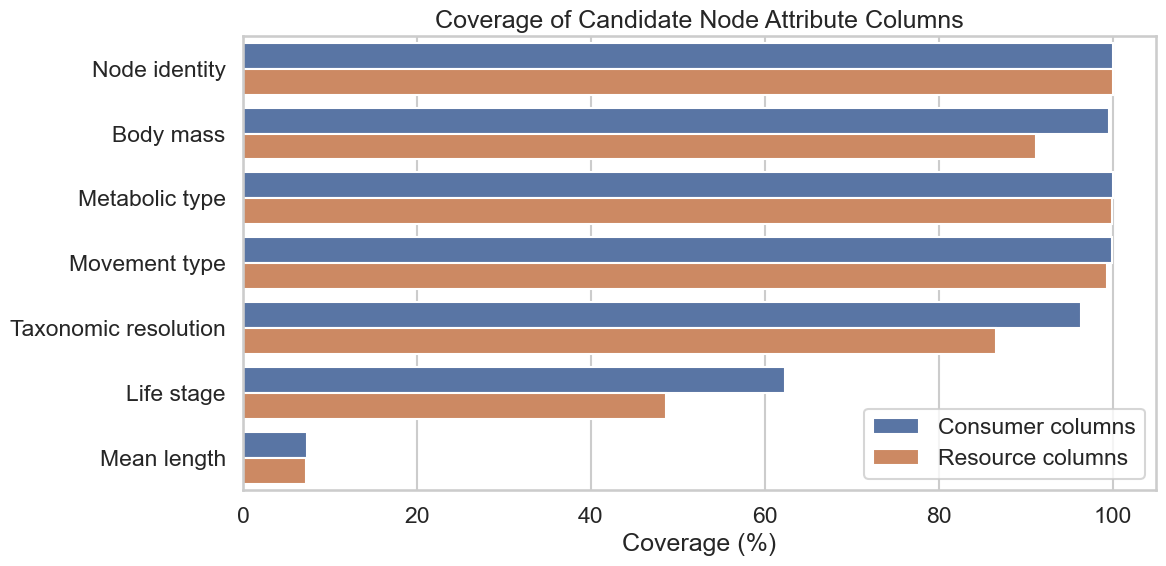

In [6]:
plot_df = coverage_df.melt(
    id_vars=["rank", "property"],
    value_vars=["consumer_coverage_pct", "resource_coverage_pct"],
    var_name="endpoint",
    value_name="coverage_pct",
)
plot_df["endpoint"] = plot_df["endpoint"].map(
    {"consumer_coverage_pct": "Consumer columns", "resource_coverage_pct": "Resource columns"}
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="coverage_pct",
    y="property",
    hue="endpoint",
    order=coverage_df["property"],
    ax=ax,
)
ax.set_xlim(0, 105)
ax.set_xlabel("Coverage (%)")
ax.set_ylabel("")
ax.set_title("Coverage of Candidate Node Attribute Columns")
ax.legend(title="")
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "candidate_column_coverage.png", dpi=200, bbox_inches="tight")
plt.show()

## Optional Global/Site-Level Variables

Some variables have high coverage but are not part of the default node attribute matrix. They are better treated as optional secondary experiments because they describe the whole food web or study site, not a species/node.

In [7]:
optional_specs = [
    ("ecosystem.type", "text", "Potentially useful as web-level context; excluded from default to keep first model node-trait focused."),
    ("geographic.location", "text", "High risk of memorising study identity; not a biological node trait."),
    ("study.site", "text", "High risk of site/study memorisation; not a biological node trait."),
    ("longitude", "numeric", "Spatial context; useful only in a secondary global-covariate experiment."),
    ("latitude", "numeric", "Spatial context; useful only in a secondary global-covariate experiment."),
    ("sampling.start.year", "numeric", "Temporal context; incomplete and not a node trait."),
    ("sampling.end.year", "numeric", "Temporal context; incomplete and not a node trait."),
    ("sampling.time", "text", "Heterogeneous temporal descriptor; incomplete."),
]

optional_df = pd.DataFrame(
    [
        {
            "column": col,
            "coverage_pct": 100 * coverage(raw[col], kind),
            "decision": decision,
        }
        for col, kind, decision in optional_specs
    ]
).sort_values("coverage_pct", ascending=False)

optional_df

,column,coverage_pct,decision
0,ecosystem.type,100.000000,Potentially useful as web-level context; exclu...
1,geographic.location,100.000000,High risk of memorising study identity; not a ...
2,study.site,100.000000,High risk of site/study memorisation; not a bi...
3,longitude,100.000000,Spatial context; useful only in a secondary gl...
4,latitude,100.000000,Spatial context; useful only in a secondary gl...
5,sampling.start.year,71.080481,Temporal context; incomplete and not a node tr...
6,sampling.end.year,71.080481,Temporal context; incomplete and not a node tr...
7,sampling.time,53.832303,Heterogeneous temporal descriptor; incomplete.


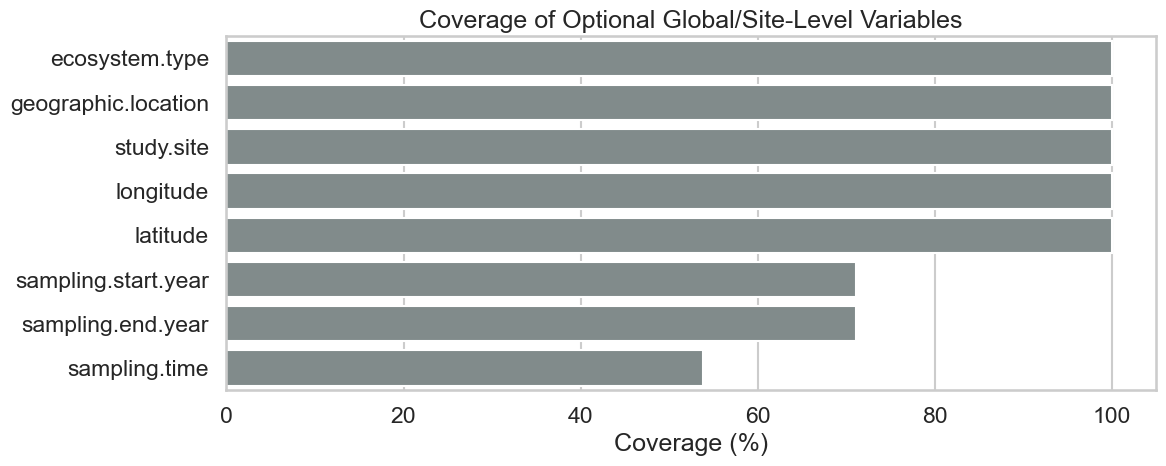

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=optional_df, x="coverage_pct", y="column", color="#7f8c8d", ax=ax)
ax.set_xlim(0, 105)
ax.set_xlabel("Coverage (%)")
ax.set_ylabel("")
ax.set_title("Coverage of Optional Global/Site-Level Variables")
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "optional_global_variable_coverage.png", dpi=200, bbox_inches="tight")
plt.show()

## Node-Level Aggregation

The raw CSV is an edge table. For SEAL/DGCNN, attributes are attached to nodes, so consumer/resource rows must be aggregated into one row per `foodweb + taxonomy` node.

The attributed `SEAL_directed` files aggregate node attributes as follows:

- mass: median of available positive values, with fallback to existing `.mat` mass,
- categorical traits: most common non-missing value,
- missing categories: encoded as `unknown`,
- missing mass: imputed with global median log-mass and marked by `mass_missing`.

In [9]:
def clean_text_series(series: pd.Series) -> pd.Series:
    text = series.astype("string").str.strip()
    return text.mask(text.str.lower().isin(MISSING_TEXT), "")


def endpoint_long(prefix: str, endpoint: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "foodweb": clean_text_series(raw["foodweb.name"]),
            "endpoint": endpoint,
            "taxonomy": clean_text_series(raw[f"{prefix}.taxonomy"]),
            "taxonomy_level": clean_text_series(raw[f"{prefix}.taxonomy.level"]),
            "lifestage": clean_text_series(raw[f"{prefix}.lifestage"]),
            "metabolic_type": clean_text_series(raw[f"{prefix}.metabolic.type"]),
            "movement_type": clean_text_series(raw[f"{prefix}.movement.type"]),
            "mass_mean_g": pd.to_numeric(raw[f"{prefix}.mass.mean.g."], errors="coerce"),
        }
    )


nodes_long = pd.concat(
    [endpoint_long("con", "consumer"), endpoint_long("res", "resource")],
    ignore_index=True,
)
nodes_long = nodes_long[(nodes_long["foodweb"] != "") & (nodes_long["taxonomy"] != "")].copy()
nodes_long["mass_valid"] = valid_numeric_mask(nodes_long["mass_mean_g"], positive=True)

node_group = nodes_long.groupby(["foodweb", "taxonomy"], sort=False)
node_coverage = pd.DataFrame(
    {
        "mass_available": node_group["mass_valid"].any(),
        "taxonomy_level_available": node_group["taxonomy_level"].agg(lambda s: (s != "").any()),
        "metabolic_type_available": node_group["metabolic_type"].agg(lambda s: (s != "").any()),
        "movement_type_available": node_group["movement_type"].agg(lambda s: (s != "").any()),
        "lifestage_available": node_group["lifestage"].agg(lambda s: (s != "").any()),
    }
).reset_index()

node_level_summary = (
    node_coverage.drop(columns=["foodweb", "taxonomy"])
    .mean()
    .mul(100)
    .rename("node_level_coverage_pct")
    .reset_index()
    .rename(columns={"index": "property"})
)
node_level_summary

,property,node_level_coverage_pct
0,mass_available,92.686184
1,taxonomy_level_available,89.031948
2,metabolic_type_available,99.951918
3,movement_type_available,99.674110
4,lifestage_available,43.353991


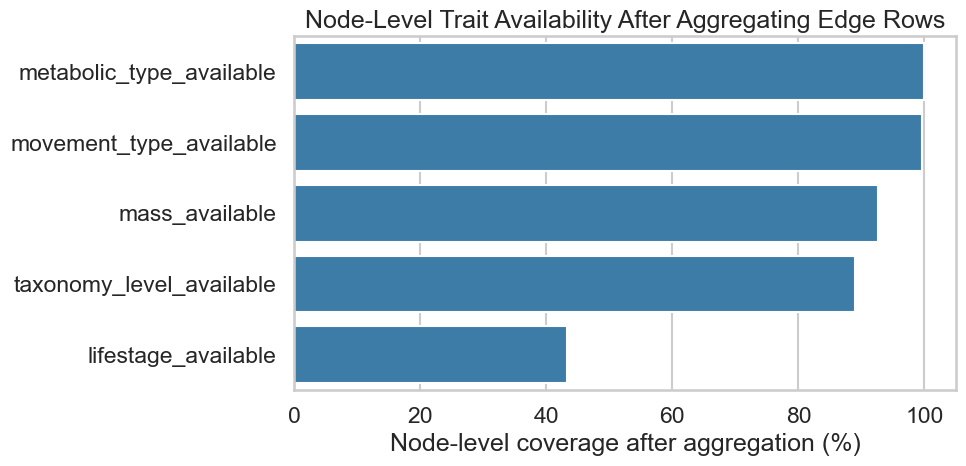

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
order = node_level_summary.sort_values("node_level_coverage_pct", ascending=False)["property"]
sns.barplot(
    data=node_level_summary,
    x="node_level_coverage_pct",
    y="property",
    order=order,
    color="#2c7fb8",
    ax=ax,
)
ax.set_xlim(0, 105)
ax.set_xlabel("Node-level coverage after aggregation (%)")
ax.set_ylabel("")
ax.set_title("Node-Level Trait Availability After Aggregating Edge Rows")
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "node_level_aggregated_coverage.png", dpi=200, bbox_inches="tight")
plt.show()

## Body Mass Distribution

Body mass is highly skewed, spanning many orders of magnitude. This justifies the `log10` transformation before z-scoring.

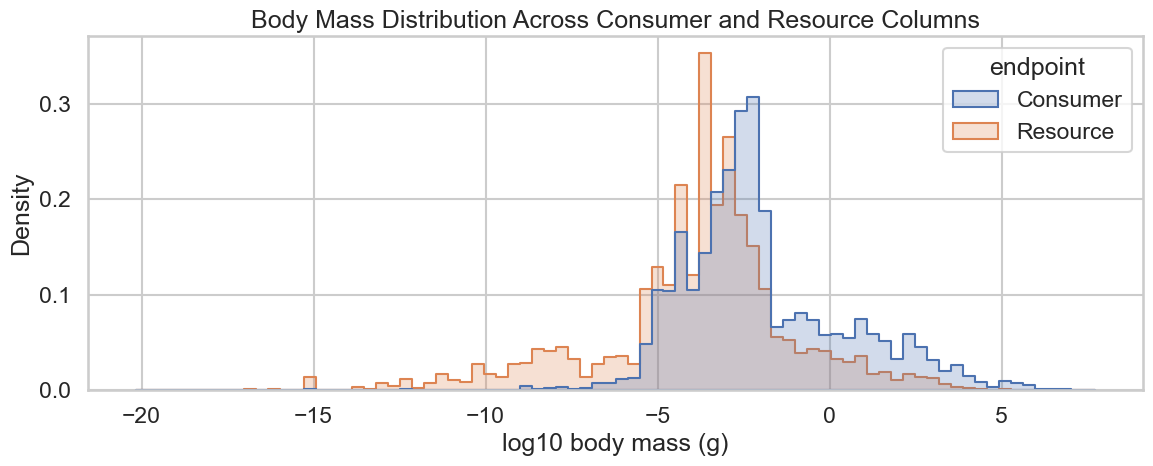

In [11]:
mass_plot = []
for label, column in [("Consumer", "con.mass.mean.g."), ("Resource", "res.mass.mean.g.")]:
    values = pd.to_numeric(raw[column], errors="coerce")
    values = values[(values.notna()) & (values != -999) & (values > 0)]
    mass_plot.append(pd.DataFrame({"endpoint": label, "log10_mass_g": np.log10(values)}))
mass_plot = pd.concat(mass_plot, ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(data=mass_plot, x="log10_mass_g", hue="endpoint", bins=80, element="step", stat="density", common_norm=False, ax=ax)
ax.set_xlabel("log10 body mass (g)")
ax.set_ylabel("Density")
ax.set_title("Body Mass Distribution Across Consumer and Resource Columns")
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "body_mass_log_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## Final Feature Matrix Check

The directed SEAL attribute builder writes a `group` matrix into each attributed `.mat` file. This section checks the generated feature set and build summary.

In [12]:
feature_names = pd.read_csv(FEATURE_NAMES_CSV)
build_summary = pd.read_csv(BUILD_SUMMARY_CSV)

print(f"Attributed MAT files: {len(list(ATTR_DIR.glob('*.mat'))):,}")
print(f"Feature count: {feature_names.shape[0]:,}")
display(feature_names.head(60))
display(build_summary.describe(include="all"))

Attributed MAT files: 290
Feature count: 44


,feature_index,feature_name
0,0,log10_mass_z
1,1,mass_missing
2,2,taxonomy_level=class
3,3,taxonomy_level=family
4,4,taxonomy_level=genus
5,5,taxonomy_level=order
6,6,taxonomy_level=species
7,7,taxonomy_level=unknown
8,8,metabolic_type=dead organic material
9,9,metabolic_type=detritus


,foodweb,status,nodes,features,missing_raw_node_attrs,mass_imputed
count,290,290,290.000000,290.0,290.0,290.000000
unique,290,1,NaN,NaN,NaN,NaN
top,AEW01_tax_mass,written,NaN,NaN,NaN,NaN
freq,1,290,NaN,NaN,NaN,NaN
mean,NaN,NaN,64.555172,44.0,0.0,4.720690
std,NaN,NaN,61.795892,0.0,0.0,11.360159
min,NaN,NaN,10.000000,44.0,0.0,0.000000
25%,NaN,NaN,23.000000,44.0,0.0,0.000000
50%,NaN,NaN,43.500000,44.0,0.0,0.000000
75%,NaN,NaN,99.000000,44.0,0.0,5.000000


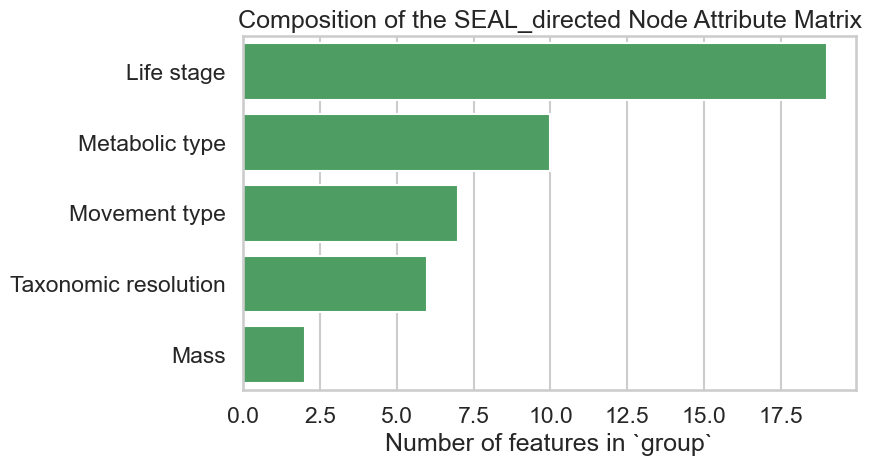

,feature_family,n_features
0,Life stage,19
1,Metabolic type,10
2,Movement type,7
3,Taxonomic resolution,6
4,Mass,2


In [13]:
def feature_family(name: str) -> str:
    if name in {"log10_mass_z", "mass_missing"}:
        return "Mass"
    if name.startswith("taxonomy_level="):
        return "Taxonomic resolution"
    if name.startswith("metabolic_type="):
        return "Metabolic type"
    if name.startswith("movement_type="):
        return "Movement type"
    if name == "lifestage_missing" or name.startswith("lifestage="):
        return "Life stage"
    return "Other"


feature_names["family"] = feature_names["feature_name"].map(feature_family)
family_counts = feature_names["family"].value_counts().rename_axis("feature_family").reset_index(name="n_features")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=family_counts, x="n_features", y="feature_family", color="#41ab5d", ax=ax)
ax.set_xlabel("Number of features in `group`")
ax.set_ylabel("")
ax.set_title("Composition of the SEAL_directed Node Attribute Matrix")
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "group_feature_composition.png", dpi=200, bbox_inches="tight")
plt.show()

family_counts

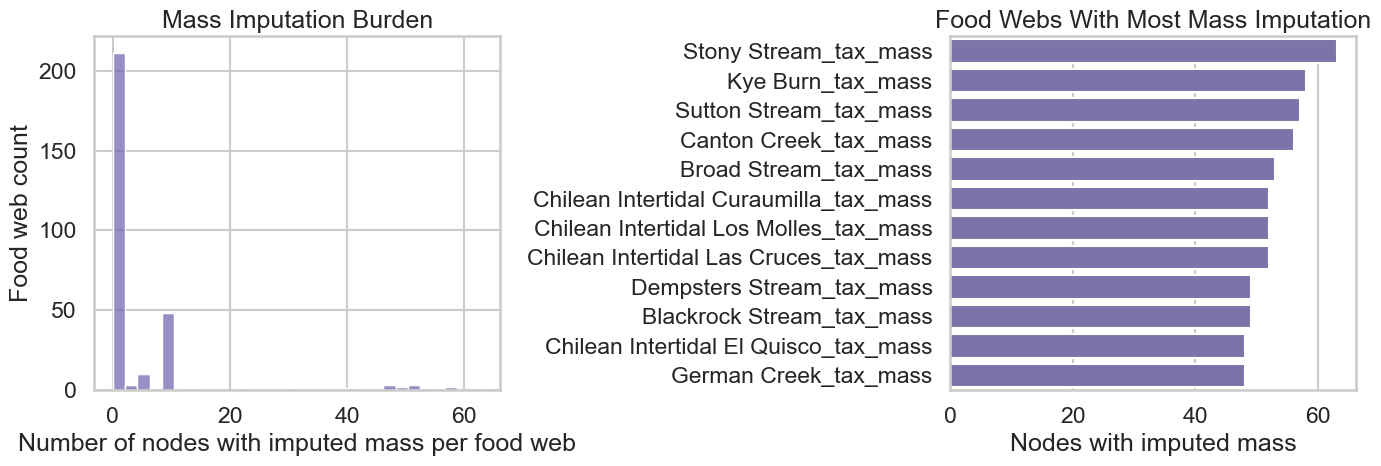

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(build_summary["mass_imputed"], bins=30, ax=axes[0], color="#756bb1")
axes[0].set_xlabel("Number of nodes with imputed mass per food web")
axes[0].set_ylabel("Food web count")
axes[0].set_title("Mass Imputation Burden")

top_imputed = build_summary.sort_values("mass_imputed", ascending=False).head(12)
sns.barplot(data=top_imputed, x="mass_imputed", y="foodweb", ax=axes[1], color="#756bb1")
axes[1].set_xlabel("Nodes with imputed mass")
axes[1].set_ylabel("")
axes[1].set_title("Food Webs With Most Mass Imputation")

plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "mass_imputation_summary.png", dpi=200, bbox_inches="tight")
plt.show()

## Final Ranking and Rationale

The final ranking is based on coverage, ecological relevance, leakage risk, and whether the feature is a node-level property compatible with the current DGCNN implementation.

In [15]:
final_ranking = coverage_df[
    [
        "rank",
        "property",
        "mean_coverage_pct",
        "ecological_relevance",
        "leakage_risk",
        "decision",
    ]
].copy()

final_ranking["used_in_current_group"] = final_ranking["property"].isin(
    ["Body mass", "Metabolic type", "Movement type", "Taxonomic resolution", "Life stage"]
)
final_ranking

,rank,property,mean_coverage_pct,ecological_relevance,leakage_risk,decision,used_in_current_group
0,1,Node identity,100.000000,5.0,Low,"Required to build nodes, not used as a numeric...",False
1,2,Body mass,95.420682,5.0,Low,Use: log10 transform + global z-score + missin...,True
2,3,Metabolic type,99.963088,4.5,Low,Use: one-hot node feature,True
3,4,Movement type,99.654739,4.0,Low,Use: one-hot node feature,True
4,5,Taxonomic resolution,91.496099,3.5,Low,Use: one-hot node feature,True
5,6,Life stage,55.528447,3.5,Low,Use cautiously: one-hot + missingness flag,True
6,7,Mean length,7.297289,3.0,Low,Exclude initially: very low coverage,False


## Interpretation

- **Body mass** is the strongest continuous trait candidate: it has high coverage and strong ecological relevance for trophic interactions.
- **Metabolic type** and **movement type** have very high coverage and encode biologically meaningful differences among producers, invertebrates, vertebrates, fungi, bacteria, sessile organisms, swimmers, walkers, etc.
- **Taxonomic resolution** is useful because not all nodes are resolved at species level. This can affect link predictability and uncertainty.
- **Life stage** is biologically relevant but has lower coverage, so it is included with an explicit missingness indicator.
---
- **Length** is excluded from the first model because coverage is too low.
- **Ecosystem/site/geographic variables** are not included in the default node attribute matrix because they are global context variables rather than species traits. They may be useful in a later secondary experiment.
- **Graph-derived structural features** are excluded from this first attribute matrix to avoid test leakage. They should only be added later if computed from each training graph after edge masking.